**Complete Analysis Notebook**

*   Data collection strategy: methodology and rationale
for chosen data sources
*   Dataset characteristics: categories covered (used cars, vegetables, etc.), time
periods, geographic scope
*   ​ Data cleaning pipeline: handling missing values, duplicates, outliers, and inconsistencies
*  Exploratory analysis: price distributions, temporal patterns, category comparisons

*  Feature engineering: extracting meaningful attributes from listings (location, condition, seasonality)
*  Development of 3+ ML models for price prediction/classification with training strategy
*   Performance evaluation: metrics comparison, cross-validation, model interpretability
*   ​ Market insights discovered: pricing trends, anomaly detection results, forecasting accuracy

*   Discussion of model strengths, limitations, and business implications

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, classification_report
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold


#DATA CLEANING PIPELINE
Handling missing values, outliers, and inconsistencies

In [2]:
df = pd.read_csv('kaggle_laptop_data.csv')

In [3]:
df.head()

,price_preview,created_at,city,spec_Etat,model_name,DEDICATED_GPU,CPU,RAM_SIZE,SSD_SIZE,HDD_SIZE,SCREEN_SIZE,SCREEN_FREQUENCY,SCREEN_RESOLUTION,RAM_TYPE
0,75000000.0,2021 10 01T18:01:44.000Z,EL TAREF,BON TAT,IDEAPAD,NaN,INTEL CORE I5 750S,4GB,128GB,NaN,14.0,NaN,NaN,NaN
1,33500000.0,2021 11 10T21:24:14.000Z,COLLO,JAMAIS UTILIS,AERO,NVIDIA GEFORCE RTX 3060,11TH GEN INTEL CORE I7 11800H,16GB,1TB,NaN,15.6,NaN,3840x2160,NaN
2,17000000.0,2021 09 11T20:27:59.000Z,MECHERIA,NaN,STEALTH,NVIDIA GEFORCE GTX 1060,INTEL CORE I7 7700HQ,16GB,NaN,NaN,17.3,120Hz,NaN,NaN
3,12000000.0,2025 03 06T00:28:39.000Z,ES SENIA,NaN,ROG,NVIDIA GEFORCE RTX 1650,AMD RYZEN 7 5800HS,16GB,512GB,NaN,14.0,NaN,NaN,NaN
4,11000000.0,2024 10 09T18:10:21.000Z,TIZI OUZOU,BON TAT,NaN,AMD RADEON RX 580,AMD RYZEN 5 2400G,16GB,128GB,145GB,NaN,60Hz,NaN,NaN


In [4]:
df.describe()

,price_preview,SCREEN_SIZE
count,1.633100e+04,14256.000000
mean,1.420100e+05,14.723777
std,7.336940e+05,5.625853
min,2.000000e+00,1.000000
25%,5.900000e+04,14.000000
50%,9.200000e+04,14.000000
75%,1.490000e+05,15.600000
max,7.500000e+07,500.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16406 entries, 0 to 16405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_preview      16331 non-null  float64
 1   created_at         16406 non-null  object 
 2   city               16333 non-null  object 
 3   spec_Etat          9600 non-null   object 
 4   model_name         15878 non-null  object 
 5   DEDICATED_GPU      3679 non-null   object 
 6   CPU                16406 non-null  object 
 7   RAM_SIZE           15952 non-null  object 
 8   SSD_SIZE           14498 non-null  object 
 9   HDD_SIZE           1166 non-null   object 
 10  SCREEN_SIZE        14256 non-null  float64
 11  SCREEN_FREQUENCY   1053 non-null   object 
 12  SCREEN_RESOLUTION  6149 non-null   object 
 13  RAM_TYPE           5347 non-null   object 
dtypes: float64(2), object(12)
memory usage: 1.8+ MB


In [6]:
df.isnull().sum()

,0
price_preview,75
created_at,0
city,73
spec_Etat,6806
model_name,528
DEDICATED_GPU,12727
CPU,0
RAM_SIZE,454
SSD_SIZE,1908
HDD_SIZE,15240


In [7]:
df_dub=df.duplicated()
print(df_dub)

0        False
1        False
2        False
3        False
4        False
         ...  
16401    False
16402    False
16403    False
16404    False
16405    False
Length: 16406, dtype: bool


In [8]:
df.shape

(16406, 14)

In [9]:
df.columns

Index(['price_preview', 'created_at', 'city', 'spec_Etat', 'model_name',
       'DEDICATED_GPU', 'CPU', 'RAM_SIZE', 'SSD_SIZE', 'HDD_SIZE',
       'SCREEN_SIZE', 'SCREEN_FREQUENCY', 'SCREEN_RESOLUTION', 'RAM_TYPE'],
      dtype='object')

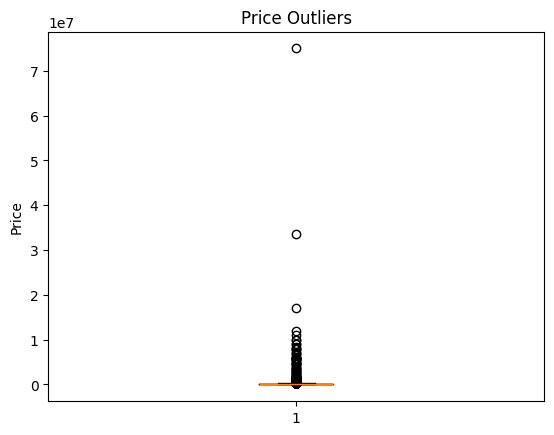

In [10]:
plt.boxplot(df['price_preview'].dropna())
plt.ylabel("Price")
plt.title("Price Outliers")
plt.show()

In [11]:
# 1.1 Fix Price Inconsistencies (Currency Mixing)
# Problem: Some prices are in DZD (e.g., 75000), others in Centimes (e.g., 7500000)
def clean_currency_mix(val):
    if pd.isna(val): return np.nan
    # If price is > 2 Million, it's definitely Centimes. Divide by 100.
    if val > 2000000:
        return val / 100
    return val

df['price_clean'] = df['price_preview'].apply(clean_currency_mix)

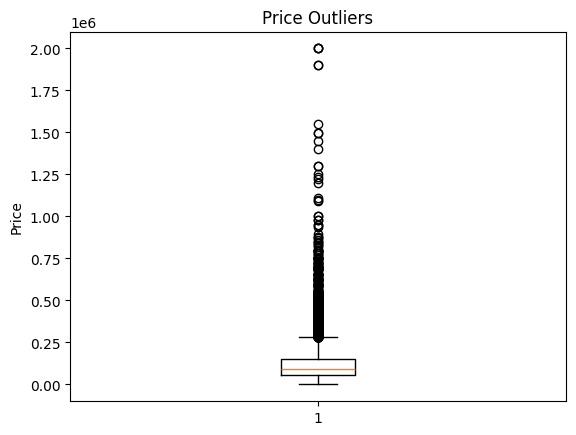

In [12]:
plt.boxplot(df['price_clean'].dropna())
plt.ylabel("Price")
plt.title("Price Outliers")
plt.show()

In [13]:
# We remove items < 15k (accessories) and > 800k (likely errors or servers)
df_clean = df.dropna(subset=['price_clean'])
df_clean = df_clean[
    (df_clean['price_clean'] > 15000) &
    (df_clean['price_clean'] < 700000)
].copy()

In [14]:
df_clean.shape

(15493, 15)

In [15]:
df_clean.to_csv('cleaned_data.csv', index=False)

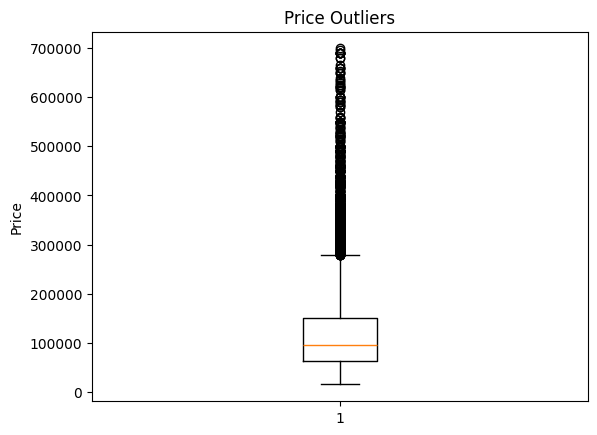

In [16]:
plt.boxplot(df_clean['price_clean'])
plt.ylabel("Price")
plt.title("Price Outliers")
plt.show()

Feature Engineering

In [17]:
#  RAM (Text -> Number)
def parse_ram(text):
    match = re.search(r"(\d+)", str(text))
    return int(match.group(1)) if match else 0

#  Storage (SSD + HDD, Convert TB to GB)
def parse_storage(text):
    text = str(text).upper()
    match = re.search(r"(\d+)", text)
    if not match: return 0
    val = int(match.group(1))
    return val * 1024 if 'TB' in text else val

#  CPU Information (Type & Generation)
def extract_cpu_info(text):
    text = str(text).upper()
    # Determine Type
    cpu_type = 'Other'
    if 'I7' in text: cpu_type = 'Core i7'
    elif 'I5' in text: cpu_type = 'Core i5'
    elif 'I3' in text: cpu_type = 'Core i3'
    elif 'I9' in text: cpu_type = 'Core i9'
    elif 'RYZEN' in text: cpu_type = 'Ryzen'
    elif 'M1' in text or 'M2' in text or 'M3' in text: cpu_type = 'Apple Silicon'

    gen = 0
    match_gen = re.search(r"(\d{1,2})\s*TH GEN", text)
    if match_gen:
        gen = int(match_gen.group(1))
    else:
        match_model = re.search(r"I\d[\s-](\d{3,5})", text)
        if match_model:
            num = match_model.group(1)
            gen = int(num[0]) if len(num) == 4 else int(num[:2])

    return pd.Series([cpu_type, gen])

# Gamer Detection
def is_gamer_gpu(text):
    if pd.isna(text): return 0
    text = str(text).upper()
    if any(x in text for x in ['RTX', 'GTX', 'QUDA', 'RADEON', 'RX', 'NVIDIA']):
        return 1
    return 0


# Apply
df_clean['RAM_GB'] = df_clean['RAM_SIZE'].apply(parse_ram)
df_clean['SSD_GB'] = df_clean['SSD_SIZE'].apply(parse_storage)
df_clean['HDD_GB'] = df_clean['HDD_SIZE'].apply(parse_storage)
df_clean['Total_Storage'] = df_clean['SSD_GB'] + df_clean['HDD_GB']
df_clean[['CPU_Type', 'CPU_Gen']] = df_clean['CPU'].apply(extract_cpu_info)
df_clean['Has_GPU'] = df_clean['DEDICATED_GPU'].apply(is_gamer_gpu)

# Time Features
df_clean['created_at'] = pd.to_datetime(df_clean['created_at'])
df_clean['annee'] = df_clean['created_at'].dt.year
df_clean['mois'] = df_clean['created_at'].dt.month
date_ref = pd.Timestamp.now(tz='UTC')
df_clean['days_since_posted'] = (date_ref - df_clean['created_at']).dt.days
df_clean['timestamp'] = df_clean['created_at'].apply(lambda x: x.timestamp())

df_clean['SCREEN_SIZE'] = df_clean['SCREEN_SIZE'].astype(str).str.replace('"','')
df_clean['SCREEN_SIZE'] = pd.to_numeric(df_clean['SCREEN_SIZE'], errors='coerce')
# median_screen_size = df_clean['SCREEN_SIZE'].median()
# df_clean['SCREEN_SIZE'] = df_clean['SCREEN_SIZE'].fillna(median_screen_size).astype(int)

df_clean['Condition'] = df_clean['spec_Etat'].fillna('Unknown')

df_clean[['price_clean','RAM_GB', 'Total_Storage', 'CPU_Type', 'CPU_Gen', 'Condition','days_since_posted','Has_GPU','model_name']].sort_values(by='price_clean').head()

,price_clean,RAM_GB,Total_Storage,CPU_Type,CPU_Gen,Condition,days_since_posted,Has_GPU,model_name
15565,15500.0,64,2048,Core i7,12,BON TAT,211,0,ELITEBOOK
15561,15500.0,32,1024,Core i9,0,Unknown,463,1,PRECISION
15560,15500.0,32,1024,Core i9,0,Unknown,463,1,PRECISION
15563,15500.0,2,500,Other,0,BON TAT,449,0,ASPIRE
15562,15500.0,8,1024,Core i3,5,MOYEN,387,0,IDEAPAD


In [18]:
df_clean=df_clean.drop(columns=['SCREEN_FREQUENCY',
       'SCREEN_RESOLUTION','city','price_preview','SSD_GB','HDD_GB','CPU','RAM_SIZE','SSD_SIZE','HDD_SIZE','DEDICATED_GPU','spec_Etat','created_at','RAM_TYPE'])

In [19]:
df_clean.columns

Index(['model_name', 'SCREEN_SIZE', 'price_clean', 'RAM_GB', 'Total_Storage',
       'CPU_Type', 'CPU_Gen', 'Has_GPU', 'annee', 'mois', 'days_since_posted',
       'timestamp', 'Condition'],
      dtype='object')

**EXPLORATORY ANALYSIS (EDA)**

/tmp/ipython-input-200387413.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_clean['price_clean'], bins=50, kde=True,palette= my_colors1)
/tmp/ipython-input-200387413.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Condition', y='price_clean', order=order,palette=my_colors)
/tmp/ipython-input-200387413.py:14: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df_clean, x='Condition', y='price_clean', order=order,palette=my_colors)


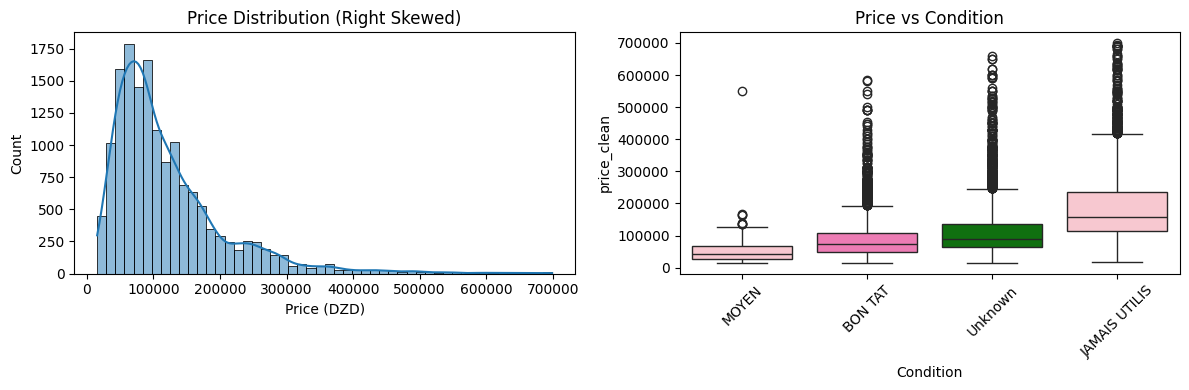

In [20]:
plt.figure(figsize=(12, 4))
my_colors = ["pink", "hotpink", "green"]
my_colors1 = ["green"]

# Plot 1: Price Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_clean['price_clean'], bins=50, kde=True,palette= my_colors1)
plt.title("Price Distribution (Right Skewed)")
plt.xlabel("Price (DZD)")

# Plot 2: Price by Condition
plt.subplot(1, 2, 2)
order = df_clean.groupby('Condition')['price_clean'].median().sort_values().index
sns.boxplot(data=df_clean, x='Condition', y='price_clean', order=order,palette=my_colors)
plt.title("Price vs Condition")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


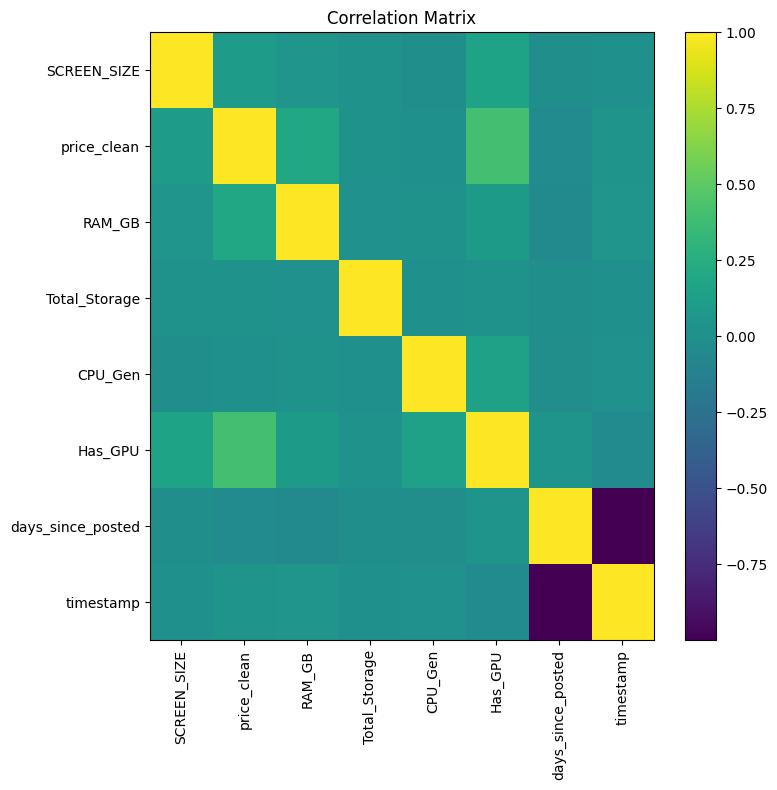

In [21]:
numeric_df_clean = df_clean.select_dtypes(include=['int64','float64'])
corr = numeric_df_clean.corr()
cols = corr.columns

plt.figure(figsize=(8, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


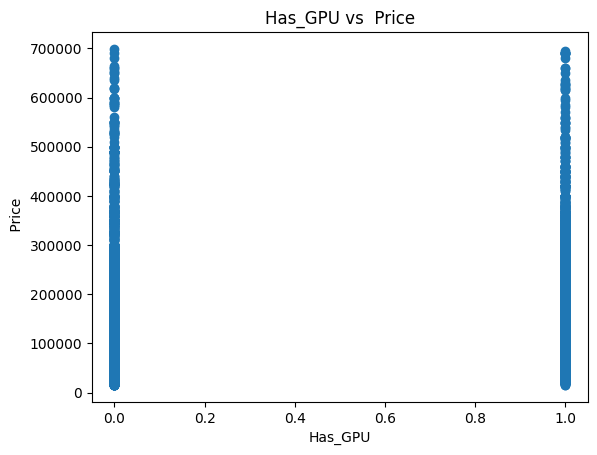

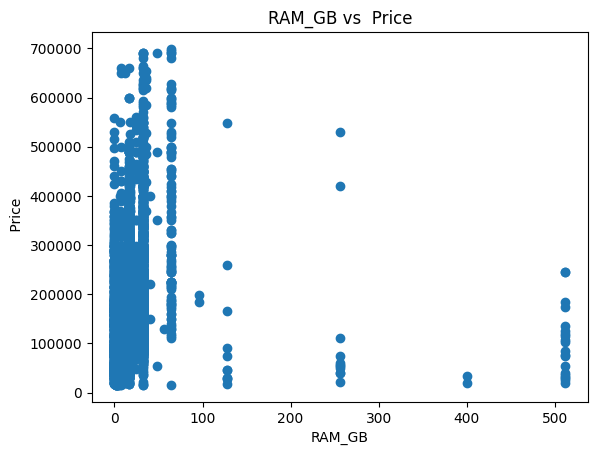

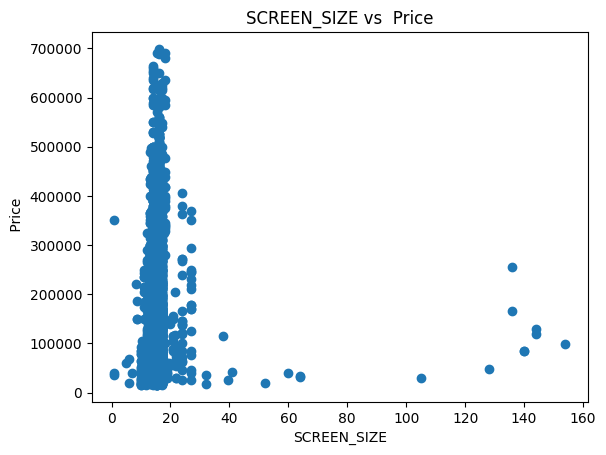

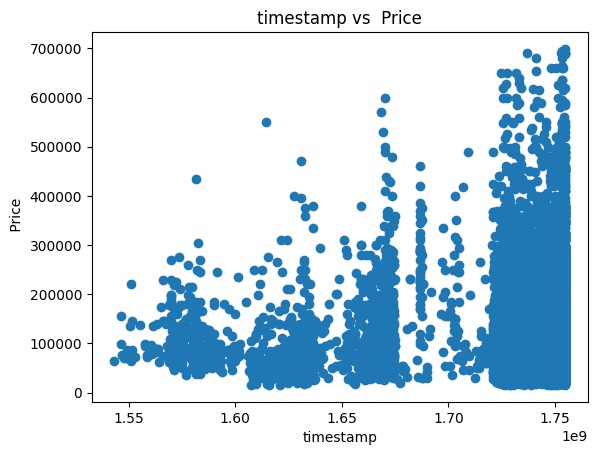

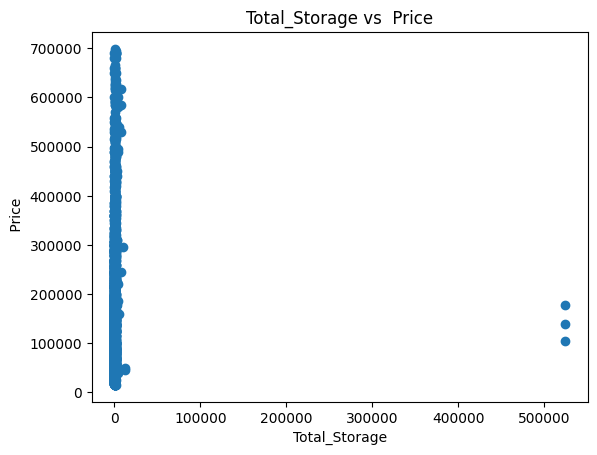

In [22]:
numeric_cols = df_clean.select_dtypes(include=['int64','float64']).columns
corr = df_clean[numeric_cols].corr()['price_clean'].sort_values(ascending=False)
important = corr[1:6].index

for col in important:
    plt.scatter(df_clean[col], df_clean['price_clean'])
    plt.xlabel(col)
    plt.ylabel(" Price")
    plt.title(f"{col} vs  Price")
    plt.show()

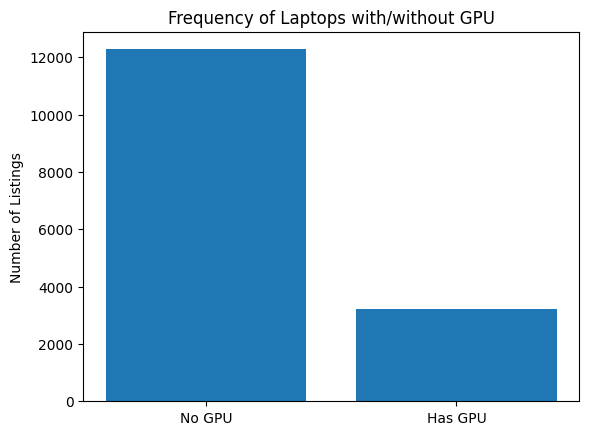

In [23]:
#  have GPU vs no GPU
gpu_counts = df_clean['Has_GPU'].value_counts().sort_index()  # 0 = no GPU, 1 = GPU

plt.bar(['No GPU', 'Has GPU'], gpu_counts)
plt.ylabel('Number of Listings')
plt.title('Frequency of Laptops with/without GPU')
plt.show()

**ML MODEL DEVELOPMENT**              
Training 3 Models with Training Strategy

We won't use : SCREEN_FREQUENCY	(null=15353)
SCREEN_RESOLUTION	(null=10257)
RAM_TYPE	(null=11059)

In [24]:

numeric_features = ['RAM_GB', 'Total_Storage', 'CPU_Gen', 'Has_GPU','SCREEN_SIZE','days_since_posted']
categorical_features = ['CPU_Type', 'Condition','model_name']

 One-Hot Encode Categorical Features


In [25]:
df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)

Define X and y


In [26]:
features = numeric_features + [c for c in df_encoded.columns if c.startswith('CPU_Type_') or c.startswith('Condition_') or c.startswith('model_name_')]
X = df_encoded[features]
print(X.columns)

Index(['RAM_GB', 'Total_Storage', 'CPU_Gen', 'Has_GPU', 'SCREEN_SIZE',
       'days_since_posted', 'CPU_Type_Core i3', 'CPU_Type_Core i5',
       'CPU_Type_Core i7', 'CPU_Type_Core i9', 'CPU_Type_Other',
       'CPU_Type_Ryzen', 'Condition_JAMAIS UTILIS', 'Condition_MOYEN',
       'Condition_Unknown', 'model_name_ALIENWARE', 'model_name_ASPIRE',
       'model_name_BLADE', 'model_name_COMPAQ', 'model_name_DYNABOOK',
       'model_name_ELITEBOOK', 'model_name_ENVY', 'model_name_GALAXY',
       'model_name_GF', 'model_name_IDEAPAD', 'model_name_IMAC',
       'model_name_INSPIRON', 'model_name_KATANA', 'model_name_LATITUDE',
       'model_name_LEGION', 'model_name_MAC', 'model_name_MACBOOK',
       'model_name_NITRO', 'model_name_OMEN', 'model_name_OPTIPLEX',
       'model_name_PAVILION', 'model_name_PRECISION', 'model_name_PREDATOR',
       'model_name_PROBOOK', 'model_name_ROG', 'model_name_SPECTRE',
       'model_name_SPIN', 'model_name_STEALTH', 'model_name_STRIX',
       'model_name_S

In [27]:
X.dtypes

,0
RAM_GB,int64
Total_Storage,int64
CPU_Gen,int64
Has_GPU,int64
SCREEN_SIZE,float64
days_since_posted,int64
CPU_Type_Core i3,bool
CPU_Type_Core i5,bool
CPU_Type_Core i7,bool
CPU_Type_Core i9,bool


In [28]:
# Log-Transform
y_log = np.log1p(df_clean['price_clean'])

In [29]:
print(y_log)

1        12.721889
2        12.043560
3        11.695255
4        11.608245
5        11.512935
           ...    
15561     9.648660
15562     9.648660
15563     9.648660
15564     9.648660
15565     9.648660
Name: price_clean, Length: 15493, dtype: float64


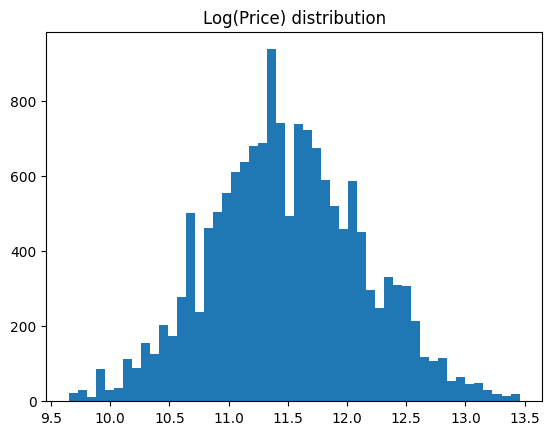

In [30]:
# X-axis -> price_amount / Y-axis->frequency
plt.hist(np.log1p(df_clean['price_clean']), bins=50)
plt.title("Log(Price) distribution")
plt.show()

 Train-Test Split (80/20)

In [31]:
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [32]:
train_median_screen = X_train['SCREEN_SIZE'].median()
train_mode_cpu = X_train['CPU_Gen'].mode()[0]

X_train['SCREEN_SIZE'] = X_train['SCREEN_SIZE'].fillna(train_median_screen)
X_train['CPU_Gen'] = X_train['CPU_Gen'].fillna(train_mode_cpu)

X_test['SCREEN_SIZE'] = X_test['SCREEN_SIZE'].fillna(train_median_screen)
X_test['CPU_Gen'] = X_test['CPU_Gen'].fillna(train_mode_cpu)

In [33]:
models_and_params = {
    "Linear Regression": (
        LinearRegression(),
        {}
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=42),
        {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None]
        }
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=42),
        {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]
        }
    ),
    "XGBoost": (
        XGBRegressor(random_state=42, verbosity=0),
        {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]
        }
    ),
    "Decision Tree": (
        DecisionTreeRegressor(random_state=42),
        {
            'max_depth': [5, 10, 15, 20]
        }
    )
}

results_list = []
best_models_storage = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Starting Model Selection...\n")

for name, (model, params) in models_and_params.items():
    print(f"Running GridSearchCV for {name}...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=kf,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    grid.fit(X_train, y_train_log)

    best_model = grid.best_estimator_
    best_models_storage[name] = best_model
    preds_log = best_model.predict(X_test)

    preds_dzd = np.expm1(preds_log)
    y_test_dzd = np.expm1(y_test_log)

    mae = mean_absolute_error(y_test_dzd, preds_dzd)
    r2 = r2_score(y_test_dzd, preds_dzd)

    results_list.append({
        "Model": name,
        "Test MAE (DZD)": mae,
        "Test R2": r2,
        "Best CV Score (Log MAE)": -grid.best_score_,
        "Best Params": grid.best_params_
    })

results_df = pd.DataFrame(results_list).set_index("Model")
results_df = results_df.sort_values(by="Test MAE (DZD)", ascending=True)

print("FINAL PERFORMANCE EVALUATION")
print(results_df)

print("\n")
print(f"The Best Model is: {results_df.index[0]}")


Starting Model Selection...

Running GridSearchCV for Linear Regression...
Running GridSearchCV for Random Forest...
Running GridSearchCV for Gradient Boosting...
Running GridSearchCV for XGBoost...
Running GridSearchCV for Decision Tree...
FINAL PERFORMANCE EVALUATION
                   Test MAE (DZD)   Test R2  Best CV Score (Log MAE)  \
Model                                                                  
Gradient Boosting    21358.670239  0.795329                 0.175148   
XGBoost              21408.727595  0.793128                 0.175192   
Random Forest        22084.499850  0.771591                 0.178738   
Decision Tree        26455.919010  0.691601                 0.216127   
Linear Regression    37113.581256  0.480570                 0.308326   

                                                         Best Params  
Model                                                                 
Gradient Boosting  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...  
XGBoost     

best model => XGBoosting

In [34]:
xgb_model = XGBRegressor(random_state=42, verbosity=0, n_estimators=200, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train_log)
y_pred=xgb_model.predict(X_test)
y_pred_dzd=np.expm1(y_pred)
y_test_dzd=np.expm1(y_test_log)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_pricing_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

    print("--- Model Performance Report ---")
    print(f"MAE:  {mae:,.0f} DZD")
    print(f"RMSE: {rmse:,.0f} DZD")
    print(f"R2:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}


metrics = get_pricing_metrics(y_test_dzd, y_pred_dzd)

--- Model Performance Report ---
MAE:  21,409 DZD
RMSE: 40,081 DZD
R2:   0.7931
MAPE: 18.81%


In [36]:
import joblib
final_model = best_model
#final_model.fit(X, y_log)

# Save the model
joblib.dump(final_model, 'laptop_price_regression_model.pkl')

# Save the Column Names
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("Success! Model and Columns exported.")

Success! Model and Columns exported.
